In [ ]:
# Import necessary libraries
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from transformers import pipeline
import warnings

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Set random seed for reproducibility
np.random.seed(42)

# Display plots inline
%matplotlib inline


In [2]:
# Define the dataset directory
DATASET_DIR = 'M&FDataset'  # Update this path based on your setup

# Check if the dataset directory exists
if not os.path.isdir(DATASET_DIR):
    raise FileNotFoundError(f"The dataset directory '{DATASET_DIR}' does not exist. Please check the path.")


In [3]:
# Function to load images and labels with a limit of 50 images per class
def load_dataset(dataset_dir, num_images_per_class=50):
    image_paths = []
    labels = []

    # Male Faces
    male_dir = os.path.join(dataset_dir, 'Male Faces')
    if not os.path.isdir(male_dir):
        raise FileNotFoundError(f"Directory '{male_dir}' not found.")
    male_images = [img for img in os.listdir(male_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    np.random.shuffle(male_images)
    selected_male_images = male_images[:num_images_per_class]

    for img_name in selected_male_images:
        img_path = os.path.join(male_dir, img_name)
        image_paths.append(img_path)
        labels.append('Male')

    # Female Faces
    female_dir = os.path.join(dataset_dir, 'Female Faces')
    if not os.path.isdir(female_dir):
        raise FileNotFoundError(f"Directory '{female_dir}' not found.")
    female_images = [img for img in os.listdir(female_dir) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    np.random.shuffle(female_images)
    selected_female_images = female_images[:num_images_per_class]

    for img_name in selected_female_images:
        img_path = os.path.join(female_dir, img_name)
        image_paths.append(img_path)
        labels.append('Female')

    # Create a DataFrame
    df = pd.DataFrame({
        'image_path': image_paths,
        'label': labels
    })

    return df

# Load the dataset with 50 images per class
df = load_dataset(DATASET_DIR, num_images_per_class=50)
print(f'Total samples: {len(df)}')  # Should print 100


Total samples: 100


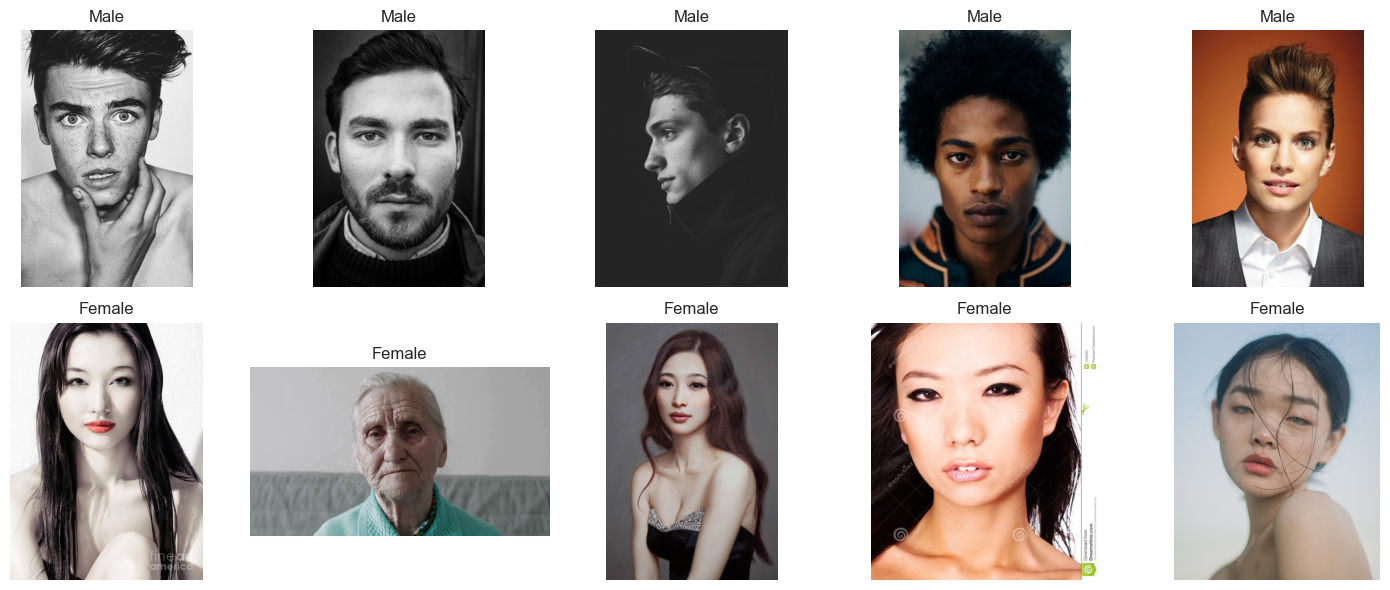

In [4]:
# Function to display sample images
def display_sample_images(df, num_samples=5):
    fig, axes = plt.subplots(2, num_samples, figsize=(15, 6))
    male_samples = df[df['label'] == 'Male'].sample(n=num_samples, random_state=42)
    female_samples = df[df['label'] == 'Female'].sample(n=num_samples, random_state=42)

    for i, (idx, row) in enumerate(male_samples.iterrows()):
        img = Image.open(row['image_path']).convert('RGB')
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        axes[0, i].set_title('Male')

    for i, (idx, row) in enumerate(female_samples.iterrows()):
        img = Image.open(row['image_path']).convert('RGB')
        axes[1, i].imshow(img)
        axes[1, i].axis('off')
        axes[1, i].set_title('Female')

    plt.tight_layout()
    plt.show()

# Display sample images
display_sample_images(df, num_samples=5)


In [5]:
# Split the data
train_df, temp_df = train_test_split(
    df,
    test_size=0.4,
    stratify=df['label'],
    random_state=42
)
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    stratify=temp_df['label'],
    random_state=42
)

print(f'Training samples: {len(train_df)}')   # Should be 60
print(f'Validation samples: {len(val_df)}')   # Should be 20
print(f'Testing samples: {len(test_df)}')     # Should be 20


Training samples: 60
Validation samples: 20
Testing samples: 20


In [13]:
# Initialize Pipelines
print("\nLoading Models...")

# Model 1: rizvandwiki/gender-classification
try:
    pipe_model1 = pipeline("image-classification", model="rizvandwiki/gender-classification")
    print("Model 1 (rizvandwiki/gender-classification) loaded successfully.")
except Exception as e:
    print(f"Error loading Model 1: {e}")

# Model 2: mrm8488/mobilevit-small-finetuned-agegender
try:
    # Model 2: mrm8488/mobilevit-small-finetuned-agegender
    pipe_model2 = pipeline("image-classification", model="rizvandwiki/gender-classification-2")
    print("Model 2 (mrm8488/mobilevit-small-finetuned-agegender) loaded successfully.")
except Exception as e:
    print(f"Error loading Model 2: {e}")



Loading Models...


Device set to use cpu


Model 1 (rizvandwiki/gender-classification) loaded successfully.


Device set to use cpu


Model 2 (mrm8488/mobilevit-small-finetuned-agegender) loaded successfully.


In [14]:
# Function to load and preprocess images
def load_and_preprocess_image(image_path):
    """
    Loads an image from the given path and preprocesses it for the model.

    Parameters:
    - image_path (str): Path to the image file.

    Returns:
    - image (PIL.Image): Preprocessed image or None if loading fails.
    """
    try:
        image = Image.open(image_path).convert('RGB')
        return image
    except Exception as e:
        print(f'Error loading image {image_path}: {e}')
        return None

# Prepare Test Images
print("\nLoading Test Images...")
test_images = []
for img_path in tqdm(test_df['image_path'], desc="Loading Test Images"):
    img = load_and_preprocess_image(img_path)
    if img is not None:
        test_images.append(img)

print(f'Total test images loaded: {len(test_images)}')  # Should be 20



Loading Test Images...


Loading Test Images: 100%|██████████| 20/20 [00:00<00:00, 124.43it/s]

Total test images loaded: 20


In [ ]:
# Function to display test images with labels
def display_test_images(df, num_samples=5):
    fig, axes = plt.subplots(4, num_samples, figsize=(15, 12))
    sampled_df = df.sample(n=num_samples, random_state=42)

    for i, (idx, row) in enumerate(sampled_df.iterrows()):
        img = Image.open(row['image_path']).convert('RGB')
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        axes[0, i].set_title(f"True: {row['label']}")

        # Placeholder for Model 1 Predictions
        axes[1, i].imshow(img)
        axes[1, i].axis('off')
        axes[1, i].set_title("Model 1: --")

        # Placeholder for Model 2 Predictions
        axes[2, i].imshow(img)
        axes[2, i].axis('off')
        axes[2, i].set_title("Model 2: --")

        # Combined Predictions (to be filled later)
        axes[3, i].imshow(img)
        axes[3, i].axis('off')
        axes[3, i].set_title("Combined: --")

    plt.tight_layout()
    plt.show()

# Display test images
display_test_images(test_df, num_samples=5)


In [16]:
# Function to parse gender labels
def parse_gender_label(label):
    """
    Parses the gender label from the model's prediction.

    Parameters:
    - label (str): The gender label predicted by the model.

    Returns:
    - gender (str): 'Male' or 'Female'. Returns 'Unknown' for unrecognized labels.
    """
    if label.lower() == 'male':
        return 'Male'
    elif label.lower() == 'female':
        return 'Female'
    else:
        return 'Unknown'

# Function to make gender predictions
def make_gender_predictions(pipeline_model, images):
    """
    Makes gender predictions on a list of images using the provided pipeline.

    Parameters:
    - pipeline_model: Hugging Face pipeline for image classification.
    - images (list): List of PIL.Image objects.

    Returns:
    - predictions (list): List of predicted genders ('Male', 'Female', 'Unknown').
    """
    predictions = []
    for img in tqdm(images, desc="Predicting"):
        preds = pipeline_model(img)
        label = preds[0]['label']
        gender = parse_gender_label(label)
        predictions.append(gender)
    return predictions


In [17]:
# Make Predictions with Both Models

# Model 1 Predictions
print("\nPredicting with Model 1 (rizvandwiki/gender-classification)...")
predictions_model1 = make_gender_predictions(pipe_model1, test_images)

# Model 2 Predictions
print("\nPredicting with Model 2 (mrm8488/mobilevit-small-finetuned-agegender)...")
predictions_model2 = make_gender_predictions(pipe_model2, test_images)



Predicting with Model 1 (rizvandwiki/gender-classification)...


Predicting: 100%|██████████| 20/20 [00:04<00:00,  4.63it/s]



Predicting with Model 2 (mrm8488/mobilevit-small-finetuned-agegender)...


Predicting: 100%|██████████| 20/20 [00:04<00:00,  4.77it/s]


In [18]:
# Add Predictions to DataFrame
test_df = test_df.copy()  # To avoid SettingWithCopyWarning
test_df['pred_model1'] = predictions_model1
test_df['pred_model2'] = predictions_model2

# Display the updated DataFrame
test_df.head()


,image_path,label,pred_model1,pred_model2
73,M&FDataset\Female Faces\0 (584).jpg,Female,Female,Female
11,M&FDataset\Male Faces\1 (2041).jpg,Male,Male,Female
78,M&FDataset\Female Faces\0 (1404).jpg,Female,Female,Female
68,M&FDataset\Female Faces\0 (2096).jpg,Female,Female,Female
47,M&FDataset\Male Faces\1 (760).jpg,Male,Male,Male


In [19]:
# Data Cleaning: Remove 'Unknown' Predictions
evaluation_df = test_df[
    (test_df['pred_model1'] != 'Unknown') &
    (test_df['pred_model2'] != 'Unknown')
].reset_index(drop=True)
print(f'\nEvaluation DataFrame shape: {evaluation_df.shape}')  # Should be <=20

if evaluation_df.empty:
    print("\nError: No valid predictions found. Please check the label parsing logic and model outputs.")
    exit()



Evaluation DataFrame shape: (20, 4)


In [20]:
# True Labels
true_labels = evaluation_df['label']

# Predictions
pred_labels_model1 = evaluation_df['pred_model1']
pred_labels_model2 = evaluation_df['pred_model2']


In [21]:
# Calculate Metrics for Model 1
accuracy1 = accuracy_score(true_labels, pred_labels_model1)
precision1 = precision_score(true_labels, pred_labels_model1, pos_label='Male')
recall1 = recall_score(true_labels, pred_labels_model1, pos_label='Male')
f1_1 = f1_score(true_labels, pred_labels_model1, pos_label='Male')

print("\n----- Model 1 (rizvandwiki/gender-classification) -----")
print(f"Accuracy: {accuracy1:.2f}")
print(f"Precision (Male): {precision1:.2f}")
print(f"Recall (Male): {recall1:.2f}")
print(f"F1-Score (Male): {f1_1:.2f}")
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels_model1))



----- Model 1 (rizvandwiki/gender-classification) -----
Accuracy: 0.90
Precision (Male): 1.00
Recall (Male): 0.80
F1-Score (Male): 0.89

Classification Report:
              precision    recall  f1-score   support

      Female       0.83      1.00      0.91        10
        Male       1.00      0.80      0.89        10

    accuracy                           0.90        20
   macro avg       0.92      0.90      0.90        20
weighted avg       0.92      0.90      0.90        20



In [22]:
# Calculate Metrics for Model 2
accuracy2 = accuracy_score(true_labels, pred_labels_model2)
precision2 = precision_score(true_labels, pred_labels_model2, pos_label='Male')
recall2 = recall_score(true_labels, pred_labels_model2, pos_label='Male')
f1_2 = f1_score(true_labels, pred_labels_model2, pos_label='Male')

print("\n----- Model 2 (mrm8488/mobilevit-small-finetuned-agegender) -----")
print(f"Accuracy: {accuracy2:.2f}")
print(f"Precision (Male): {precision2:.2f}")
print(f"Recall (Male): {recall2:.2f}")
print(f"F1-Score (Male): {f1_2:.2f}")
print("\nClassification Report:")
print(classification_report(true_labels, pred_labels_model2))



----- Model 2 (mrm8488/mobilevit-small-finetuned-agegender) -----
Accuracy: 0.85
Precision (Male): 1.00
Recall (Male): 0.70
F1-Score (Male): 0.82

Classification Report:
              precision    recall  f1-score   support

      Female       0.77      1.00      0.87        10
        Male       1.00      0.70      0.82        10

    accuracy                           0.85        20
   macro avg       0.88      0.85      0.85        20
weighted avg       0.88      0.85      0.85        20



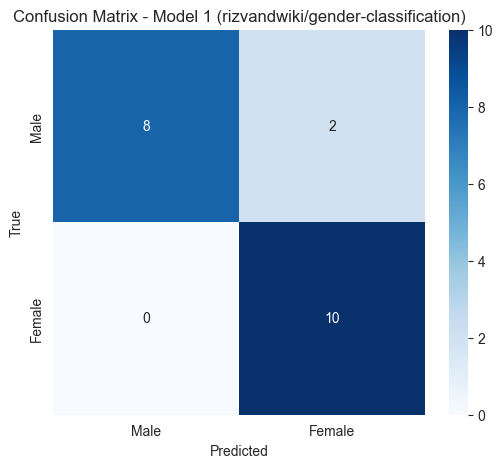

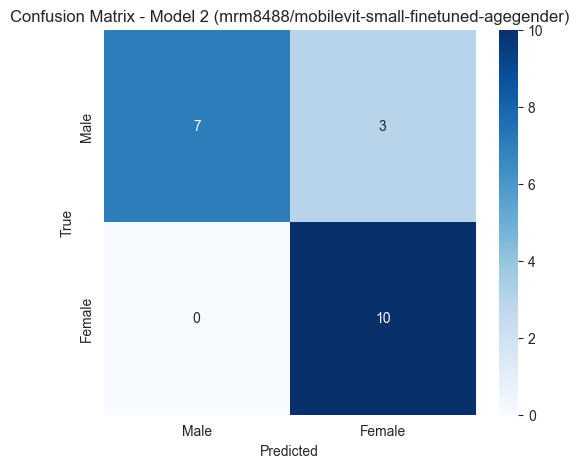

In [23]:
# Confusion Matrix for Model 1
# Function to plot confusion matrix
def plot_confusion_matrix_cm(cm, model_name):
    """
    Plots the confusion matrix.

    Parameters:
    - cm (array): Confusion matrix.
    - model_name (str): Name of the model.
    """
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Male', 'Female'],
                yticklabels=['Male', 'Female'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.show()

# Confusion Matrix for Model 1
cm1 = confusion_matrix(true_labels, pred_labels_model1, labels=['Male', 'Female'])
plot_confusion_matrix_cm(cm1, 'Model 1 (rizvandwiki/gender-classification)')

# Confusion Matrix for Model 2
cm2 = confusion_matrix(true_labels, pred_labels_model2, labels=['Male', 'Female'])
plot_confusion_matrix_cm(cm2, 'Model 2 (mrm8488/mobilevit-small-finetuned-agegender)')


In [24]:
# Function to display test images with labels and predictions

def display_test_images_with_predictions(df, num_samples=5):
    fig, axes = plt.subplots(4, num_samples, figsize=(15, 12))
    sampled_df = df.sample(n=num_samples, random_state=42)

    for i, (idx, row) in enumerate(sampled_df.iterrows()):
        img = Image.open(row['image_path']).convert('RGB')
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        axes[0, i].set_title(f"True: {row['label']}")

        # Model 1 Predictions
        axes[1, i].imshow(img)
        axes[1, i].axis('off')
        axes[1, i].set_title(f"Model 1: {row['pred_model1']}")

        # Model 2 Predictions
        axes[2, i].imshow(img)
        axes[2, i].axis('off')
        axes[2, i].set_title(f"Model 2: {row['pred_model2']}")

        # Combined Predictions
        combined_pred = row['pred_model1'] if row['pred_model1'] == row['pred_model2'] else 'Different'
        axes[3, i].imshow(img)
        axes[3, i].axis('off')
        axes[3, i].set_title(f"Combined: {combined_pred}")

    plt.tight_layout()
    plt.show()

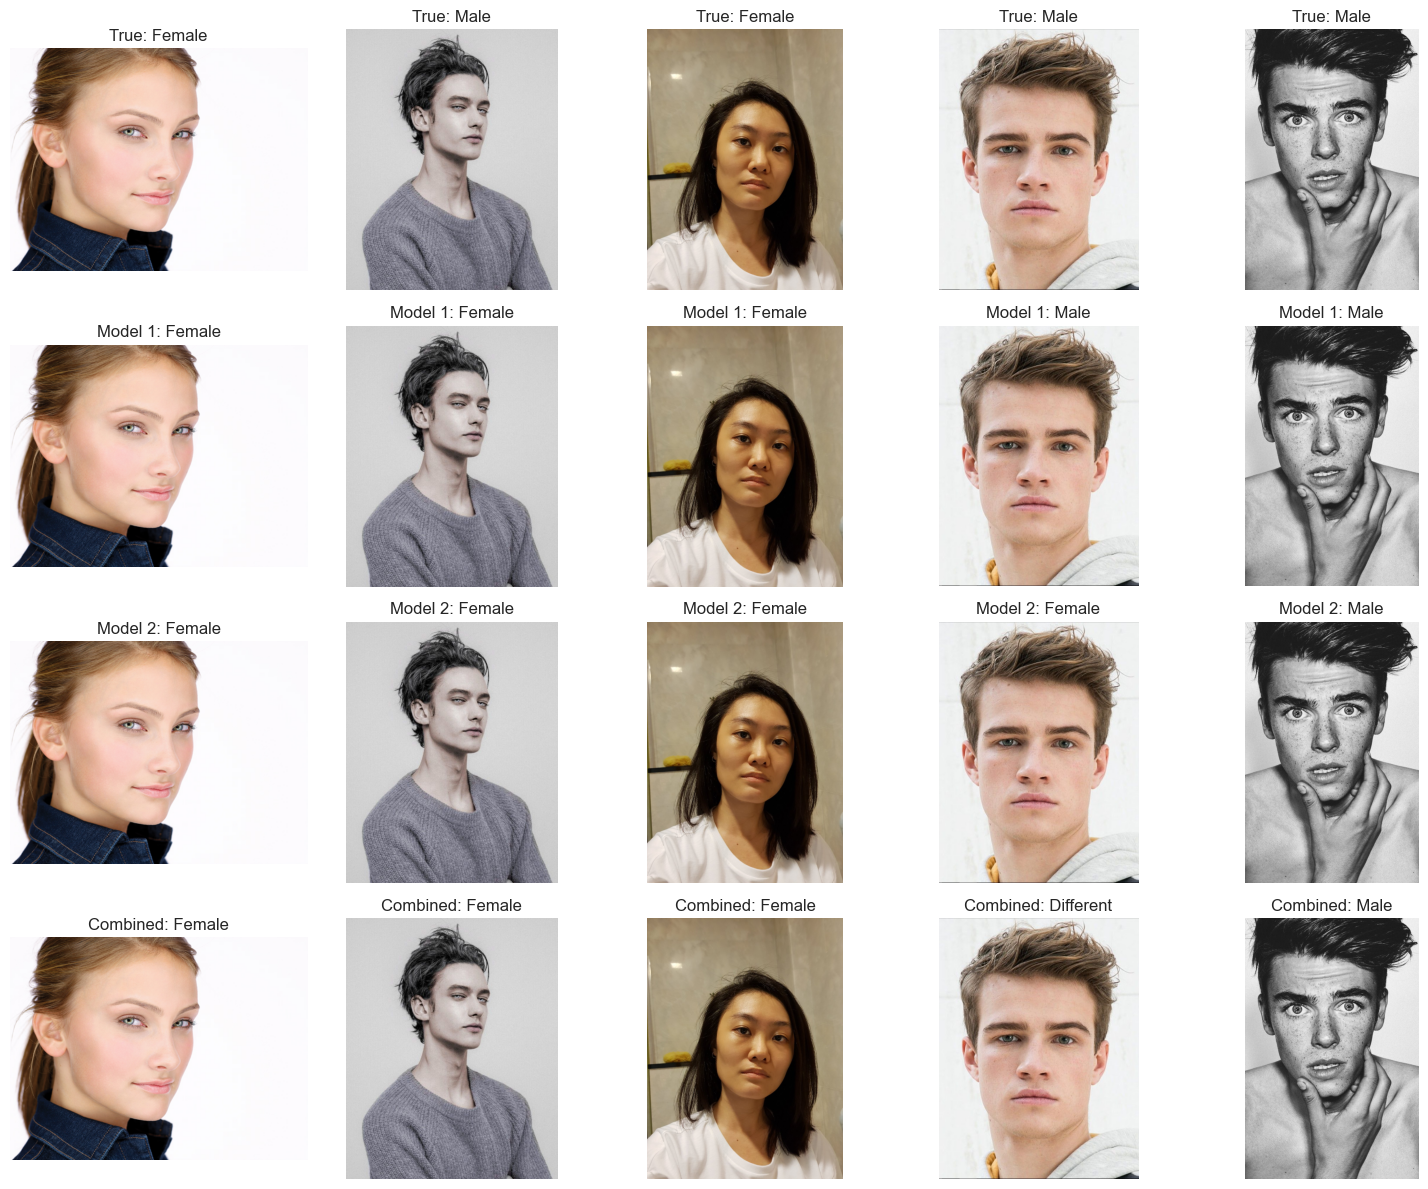

In [25]:
# Display test images with labels and predictions
display_test_images_with_predictions(test_df, num_samples=5)



In [40]:
from transformers import ViTFeatureExtractor, ViTForImageClassification
from PIL import Image
import torch

# Replace 'your-face-gender-model' with the actual model name trained for face gender classification
model_name = "ufdatastudio/vit-gender"
feature_extractor = ViTFeatureExtractor.from_pretrained(model_name)
model = ViTForImageClassification.from_pretrained(model_name)

def classify_gender(image_path):
    img = Image.open(image_path).convert("RGB")

    # Preprocess the image
    inputs = feature_extractor(images=img, return_tensors="pt")

    # Run inference (classify the image)
    with torch.no_grad():
        outputs = model(**inputs)

    # Get predicted class
    predicted_class_idx = outputs.logits.argmax(-1).item()
    labels = model.config.id2label  # get labels
    predicted_label = labels[predicted_class_idx]

    return predicted_label

# Example usage
image_path = r"C:\Users\muham\PycharmProjects\pythonProject\face_gender\M&FDataset\Female Faces\0 (5).jpg"
gender = classify_gender(image_path)
print(f"Predicted Gender: {gender}")


preprocessor_config.json:   0%|          | 0.00/325 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/343M [00:00<?, ?B/s]

Predicted Gender: female
